# TS4: Primeras nociones de estimación espectral

En esta tarea continuaremos con el capítulo 14 de *Holton, DSP Principles and Applications.*

Comenzaremos con la generación de la siguiente señal:

$$
x(k) = a_0 \cdot \sin(\Omega_1 \cdot n) + n_a(n)
$$

donde:

$$
a_0 = 2
$$

$$
\Omega_1 = \Omega_0 + f_r \cdot \frac{2\pi}{N}
$$

$$
\Omega_0 = \frac{\pi}{2}
$$

La variable aleatoria \(f_r\) está definida por la siguiente distribución:

$$
f_r \sim U(-2, 2)
$$

y el ruido aditivo:

$$
n_a \sim \mathcal{N}(0, \sigma^2)
$$

---

## Estimadores

Se desea diseñar los siguientes estimadores de amplitud \(\hat{a}_1^i\) y frecuencia \(\hat{\Omega}_1^i\):

### Estimador de amplitud

$$
\hat{a}_1^i = \left| X_w^i(\Omega_0) \right| = \left| \mathcal{F}\{ x(n)\, w_i(n) \} \right|
$$

### Estimador de frecuencia

$$
\hat{\Omega}_1^i = \arg\max_{\Omega} \left| X_w^i(\Omega) \right|
$$

para cada una de las siguientes ventanas:

- rectangular (sin ventana)  
- flattop  
- blackmanharris  
- otra a elección de `scipy.signal.windows`

---

## Consignas de experimentación

- Considere **200 realizaciones** (muestras de \(f_r\)) de **1000 muestras** cada una.  
- Parametrice para **SNR = 3 dB** y **SNR = 10 dB**.  
- *Ayuda:* calibre \(a_1\) para que la potencia de la senoidal sea **1 W**.

---

## Cálculo del sesgo y la varianza

Para el estimador de amplitud:

$$
\hat{a}_0 = |X_w(\Omega_0)|
$$

Sesgo:

$$
s_a = \mathbb{E}\{\hat{a}_0\} - a_0
$$

Varianza:

$$
v_a = \mathrm{var}\{\hat{a}_0\} = \mathbb{E}\left[(\hat{a}_0 - \mathbb{E}\{\hat{a}_0\})^2\right]
$$

Aproximación mediante medias muestrales (con \(M\) realizaciones):

$$
\mathbb{E}\{\hat{a}_0\} \approx \mu_{\hat{a}} = \frac{1}{M}\sum_{j=0}^{M-1} \hat{a}_j
$$

$$
s_a = \mu_{\hat{a}} - a_0
$$

$$
v_a = \frac{1}{M}\sum_{j=0}^{M-1} (\hat{a}_j - \mu_{\hat{a}})^2
$$

---

## Tablas solicitadas

### Estimación de Amplitud

| Ventana        | \($s_a$\) (10 dB) | \($v_a$\) (10 dB) | \($s_a$\) (3 dB) | \($v_a$\) (3 dB) |
|----------------|----------------:|----------------:|----------------:|----------------:|
| Rectangular    | -0.9060 | 0.21338 | -0.9059 | 0.21439 |
| Flat-top       | -1.1374 | 0.00119 | -1.1369 | 0.00129 |
| Blackman-Harris| -1.0864 | 0.01867 | -1.0857 | 0.01851 |
| Hamming        | -1.0630 | 0.07369 | -1.0604 | 0.07207 |

---

### Estimación de Frecuencia

| Ventana        | \($s_f$\) (10 dB) | \($v_f$\) (10 dB) | \($s_f$\) (3 dB) | \($v_f$\) (3 dB) |
|----------------|----------------:|----------------:|----------------:|----------------:|
| Rectangular    | -0.0352 | 1.5250 | -0.0252 | 1.5350 |
| Flat-top       | -0.0152 | 1.5048 | 0.0648  | 1.5060 |
| Blackman-Harris| -0.0252 | 1.5550 | -0.0202 | 1.5399 |
| Hamming        | -0.0202 | 1.5499 | -0.0252 | 1.5350 |


## Introducción

El objetivo de esta tarea es estudiar estimadores de **amplitud** y de **frecuencia** de una senoidal contaminada con ruido, y comparar su desempeño según la **ventana** aplicada antes de calcular la DFT.

El análisis se realiza utilizando:

- \(200\) realizaciones,
- cada una con una **desintonía aleatoria** distinta,
- y se evalúan el **sesgo** y la **varianza** de cada estimador.

El propósito final es observar cómo la elección de la ventana afecta la calidad de los estimadores en presencia de ruido.


## Ruido y SNR

Para cada valor de SNR (10 dB y 3 dB) se calcula la potencia de ruido necesaria mediante:

$$
P_n = \frac{P_s}{10^{\mathrm{SNR}/10}}
$$

donde:

$$
P_s = 1 \, \text{W}
$$

El desvío estándar del ruido gaussiano es:

$$
\sigma_n = \sqrt{P_n}
$$

Con \(\mathrm{SNR} = 10\,\text{dB}\), el ruido es diez veces más débil que la señal en potencia.  
Con \(\mathrm{SNR} = 3\,\text{dB}\), el ruido es solo el doble, por lo que la dispersión de los estimadores debería aumentar notablemente al disminuir el SNR.

---

## Estimador de amplitud

El estimador se define como:

$$
\text{estimador}_a = 2 \cdot \left| S_{\text{vent}}[:, N/4] \right|
$$

Es decir, se toma el módulo de la DFT en el bin central \(N/4\) y se multiplica por 2 para recuperar la amplitud completa de la senoidal real (cuya energía se reparte entre frecuencia positiva y negativa).

El sesgo se calcula como:

$$
s_a = \mu_{\hat{a}} - a_0
$$

y la varianza corresponde a la dispersión de los 200 valores obtenidos.

La ventana **flattop** debería producir el menor sesgo, ya que su lóbulo principal es plano en la cima: aun con desintonía, el valor del pico cambia muy poco, que es precisamente el objetivo de su diseño.



In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import windows

# Parámetros
N = 1000 # cantidad de muestras
R = 200 # cantidad de realizaciones
fs = 1000 # frecuencia de muestreo
df = fs / N
Ts = 1 / fs
a0 = np.sqrt(2) # amplitud
omega0 = N/4
fr = np.random.uniform(-2,2, size = R)

# Eje de muestras
n = np.arange(N)
n = n.reshape(1, N)

t = np.arange(N) / fs
tt = np.tile(t, (R,1))   # matriz 200x1000

omega1 = omega0 + fr * df
omega1 = omega1.reshape(R, 1)

ff = np.arange(N) # Vector en frecuencia al escalar las muestras por la resolucion espectral
f = omega1*n
ff = ff.reshape(1000, 1)

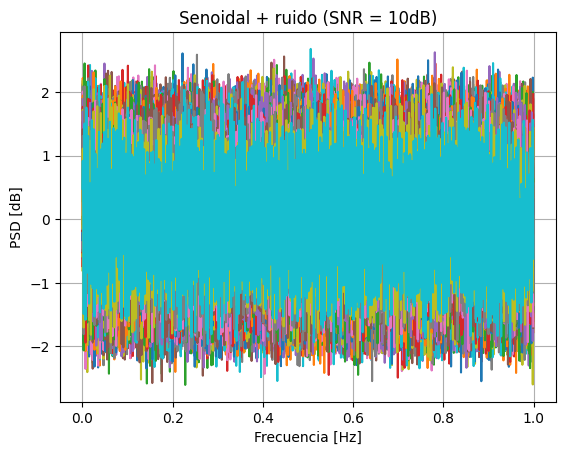

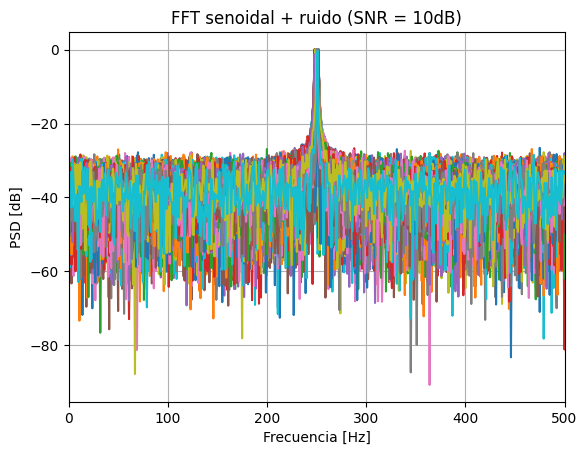

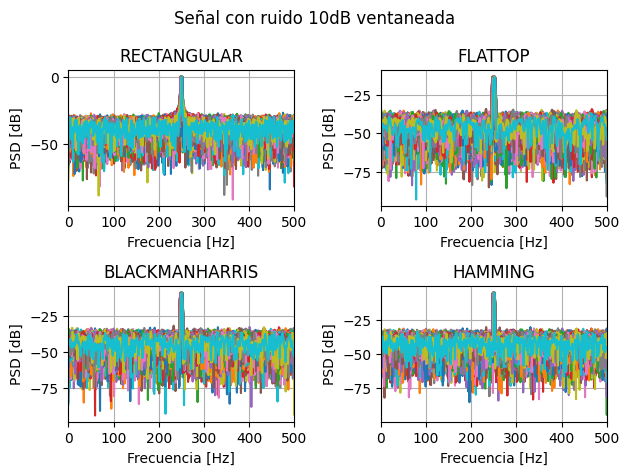

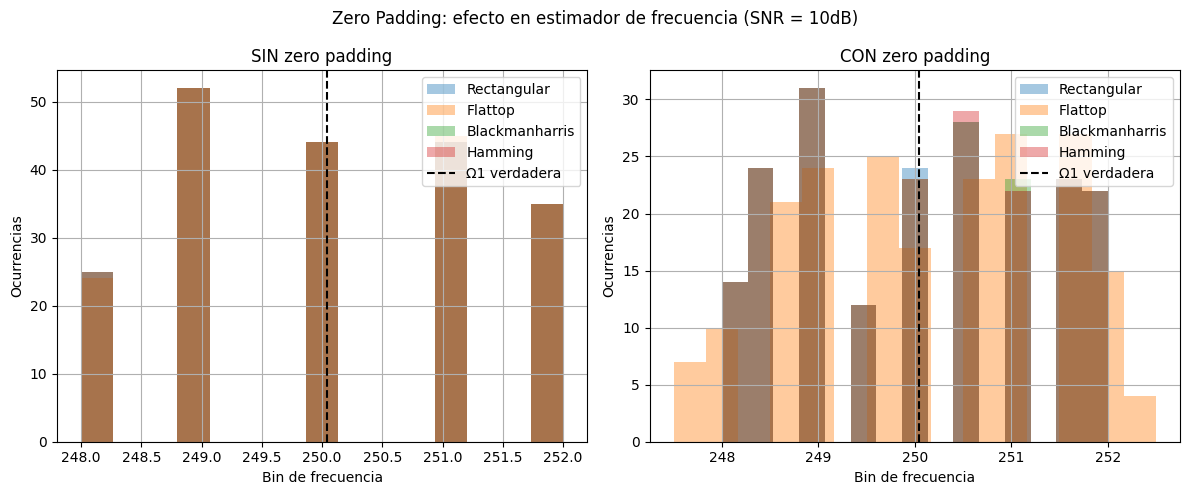

In [11]:
#%% SNR = 10dB
SNR = 10 # en dB
Ps = a0**2 / 2
Pr = Ps / (10**(SNR/10))
desvio = np.sqrt(Pr)

na = np.random.normal(0, desvio, size = (R, N)) # ruido

# Señal
s_mat_10 = a0 * np.sin(2 * np.pi * f * Ts) + na

# Traspongo la señal para poder graficarla 
señal_t10 = np.transpose(s_mat_10)

plt.figure()
plt.title("Senoidal + ruido (SNR = 10dB)")
plt.plot(t, señal_t10)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]') # Es la densidad espectral de potencia 
plt.grid()
plt.show()

# FFT
eps = 1e-12
S_mat_10 = np.fft.fft(s_mat_10, axis = 1) / N
S_mat_modulo10 = np.abs(S_mat_10)
S_mat_dB10 = 10 * np.log10(2*(S_mat_modulo10)**2 + eps)
S_mat_dB10 = np.transpose(S_mat_dB10)

plt.figure()
plt.title("FFT senoidal + ruido (SNR = 10dB)")
plt.plot(ff, S_mat_dB10)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]') # Es la densidad espectral de potencia 
plt.xlim(0, fs/2)
plt.grid()
plt.show()

#%% Ventaneo SNR = 10dB 
# RECTANGULAR
s_vent_R10 = s_mat_10 * windows.boxcar(N)

S_vent_R10 = np.fft.fft(s_vent_R10, axis=1) / N
S_vent_modulo_R10 = np.abs(S_vent_R10)
S_vent_R10_dB = 10 * np.log10(2*(S_vent_modulo_R10)**2 + eps)
S_vent_R10_dB = np.transpose(S_vent_R10_dB)

# FLATTOP
s_vent_F10 = s_mat_10 * windows.flattop(N)

S_vent_F10 = np.fft.fft(s_vent_F10, axis=1) / N
S_vent_modulo_F10 = np.abs(S_vent_F10)
S_vent_F10_dB = 10 * np.log10(2*(S_vent_modulo_F10)**2 + eps)
S_vent_F10_dB = np.transpose(S_vent_F10_dB)

# BLACKMANHARRIS
s_vent_B10 = s_mat_10 * windows.blackmanharris(N)

S_vent_B10 = np.fft.fft(s_vent_B10, axis=1) / N
S_vent_modulo_B10 = np.abs(S_vent_B10)
S_vent_B10_dB = 10 * np.log10(2*(S_vent_modulo_B10)**2 + eps)
S_vent_B10_dB = np.transpose(S_vent_B10_dB)

# HAMMING
s_vent_H10 = s_mat_10 * windows.hamming(N)

S_vent_H10 = np.fft.fft(s_vent_H10, axis=1) / N
S_vent_modulo_H10 = np.abs(S_vent_H10)
S_vent_H10_dB = 10 * np.log10(2*(S_vent_modulo_H10)**2 + eps)
S_vent_H10_dB = np.transpose(S_vent_H10_dB)

# Graficos
plt.figure()
plt.suptitle("Señal con ruido 10dB ventaneada")

plt.subplot(2,2,1)
plt.title("RECTANGULAR")
plt.plot(ff, S_vent_R10_dB)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]') # Es la densidad espectral de potencia 
plt.xlim(0, fs/2)
plt.grid()

plt.subplot(2,2,2)
plt.title("FLATTOP")
plt.plot(ff, S_vent_F10_dB)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]') # Es la densidad espectral de potencia 
plt.xlim(0, fs/2)
plt.grid()

plt.subplot(2,2,3)
plt.title("BLACKMANHARRIS")
plt.plot(ff, S_vent_B10_dB)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]') # Es la densidad espectral de potencia 
plt.xlim(0, fs/2)
plt.grid()

plt.subplot(2,2,4)
plt.title("HAMMING")
plt.plot(ff, S_vent_H10_dB)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]') # Es la densidad espectral de potencia 
plt.xlim(0, fs/2)
plt.grid()

plt.tight_layout()
plt.show()

#%% Estimador de amplitud SNR = 10dB
# SNR = 10dB
estimador_a_R10 = np.abs(S_vent_R10[:, N//4])*2
estimador_a_F10 = np.abs(S_vent_F10[:, N//4])*2
estimador_a_B10 = np.abs(S_vent_B10[:, N//4])*2
estimador_a_H10 = np.abs(S_vent_H10[:, N//4])*2

#%% SESGO Y VARIANZA SNR = 10dB
sesgo_amp_R10 = np.mean(estimador_a_R10) - a0 
sesgo_amp_F10 = np.mean(estimador_a_F10) - a0 
sesgo_amp_B10 = np.mean(estimador_a_B10) - a0 
sesgo_amp_H10 = np.mean(estimador_a_H10) - a0 

varianza_amp_R10 = np.var(estimador_a_R10)
varianza_amp_F10 = np.var(estimador_a_F10)
varianza_amp_B10 = np.var(estimador_a_B10)
varianza_amp_H10 = np.var(estimador_a_H10)

#%% Estimador de la frecuencia SNR = 10dB
estimador_f_R10 = np.argmax(np.abs(S_vent_R10[:, :N//2]), axis = 1)
estimador_f_F10 = np.argmax(np.abs(S_vent_F10[:, :N//2]), axis = 1)
estimador_f_B10 = np.argmax(np.abs(S_vent_B10[:, :N//2]), axis = 1)
estimador_f_H10 = np.argmax(np.abs(S_vent_H10[:, :N//2]), axis = 1)

#%% SESGO Y VARIANZA SNR = 10dB
sesgo_frec_R10 = np.mean(estimador_f_R10) - np.mean(omega1)
sesgo_frec_F10 = np.mean(estimador_f_F10) - np.mean(omega1)
sesgo_frec_B10 = np.mean(estimador_f_B10) - np.mean(omega1)
sesgo_frec_H10 = np.mean(estimador_f_H10) - np.mean(omega1)

varianza_frec_R10 = np.var(estimador_f_R10)
varianza_frec_F10 = np.var(estimador_f_F10)
varianza_frec_B10 = np.var(estimador_f_B10)
varianza_frec_H10 = np.var(estimador_f_H10)

#%% Efecto del zero padding en el estimador de frecuencia (SNR = 10dB)
N_zp = 2 * N  # 2000 puntos

# Rectangular
zp_W_R10 = np.fft.fft(s_vent_R10, n = N_zp, axis = 1)
estimador_f_zp_R10 = np.argmax(np.abs(zp_W_R10[:, :N_zp//2]), axis = 1) / 2
# Dividir por 2 porque los bins ahora son la mitad de anchos

# Flattop
zp_W_F10 = np.fft.fft(s_vent_F10, n = N_zp, axis  =1)
estimador_f_zp_F10 = np.argmax(np.abs(zp_W_F10[:, :N_zp//2]), axis = 1) / 2

# Blackmanharris
zp_W_B10 = np.fft.fft(s_vent_B10, n = N_zp, axis = 1)
estimador_f_zp_B10 = np.argmax(np.abs(zp_W_B10[:, :N_zp//2]), axis = 1) / 2

# Hamming
zp_W_H10 = np.fft.fft(s_vent_H10, n = N_zp, axis = 1)
estimador_f_zp_H10 = np.argmax(np.abs(zp_W_H10[:, :N_zp//2]), axis = 1) / 2

# Sesgo y varianza CON zero padding
sesgo_f_zp_R10 = np.mean(estimador_f_zp_R10) - np.mean(omega1)
sesgo_f_zp_F10 = np.mean(estimador_f_zp_F10) - np.mean(omega1)
sesgo_f_zp_B10 = np.mean(estimador_f_zp_B10) - np.mean(omega1)
sesgo_f_zp_H10 = np.mean(estimador_f_zp_H10) - np.mean(omega1)

var_f_zp_R10 = np.var(estimador_f_zp_R10)
var_f_zp_F10 = np.var(estimador_f_zp_F10)
var_f_zp_B10 = np.var(estimador_f_zp_B10)
var_f_zp_H10 = np.var(estimador_f_zp_H10)

#%% Histograma comparativo ZP vs sin ZP
plt.figure(figsize=(12, 5))
plt.suptitle("Zero Padding: efecto en estimador de frecuencia (SNR = 10dB)")

plt.subplot(1, 2, 1)
plt.title("SIN zero padding")
plt.hist(estimador_f_R10, label = 'Rectangular', alpha = 0.4, bins = 15)
plt.hist(estimador_f_F10,  label = 'Flattop', alpha = 0.4, bins = 15)
plt.hist(estimador_f_B10,  label = 'Blackmanharris', alpha = 0.4, bins = 15)
plt.hist(estimador_f_H10,  label = 'Hamming', alpha = 0.4, bins = 15)
plt.axvline(np.mean(omega1), color = 'k', linestyle = '--', label = 'Ω1 verdadera')
plt.xlabel('Bin de frecuencia')
plt.ylabel('Ocurrencias')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.title("CON zero padding")
plt.hist(estimador_f_zp_R10,      label = 'Rectangular', alpha = 0.4, bins = 15)
plt.hist(estimador_f_zp_F10,     label='Flattop', alpha = 0.4, bins = 15)
plt.hist(estimador_f_zp_B10, label='Blackmanharris', alpha = 0.4, bins = 15)
plt.hist(estimador_f_zp_H10,      label='Hamming',        alpha = 0.4, bins = 15)
plt.axvline(np.mean(omega1), color = 'k', linestyle = '--', label = 'Ω1 verdadera')
plt.xlabel('Bin de frecuencia')
plt.ylabel('Ocurrencias')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

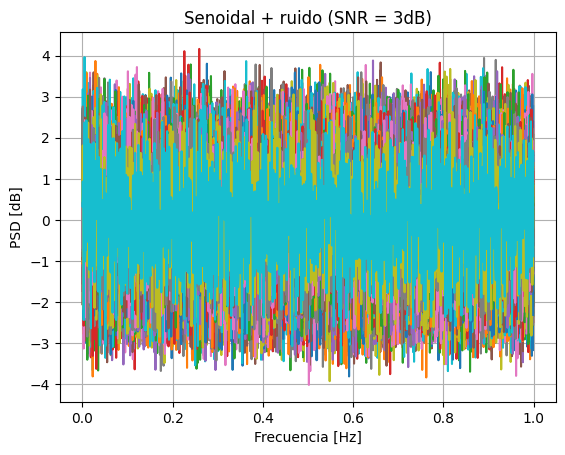

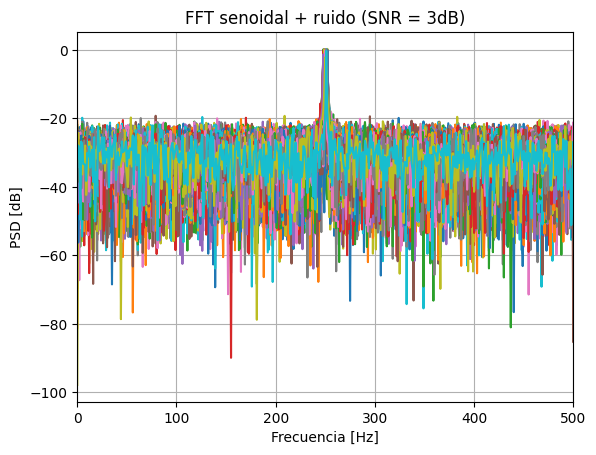

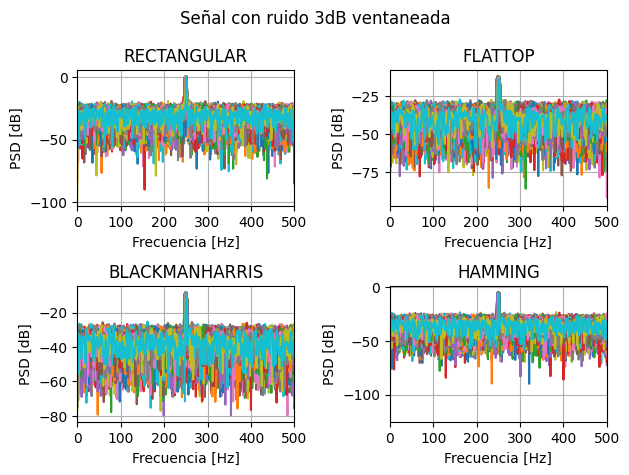

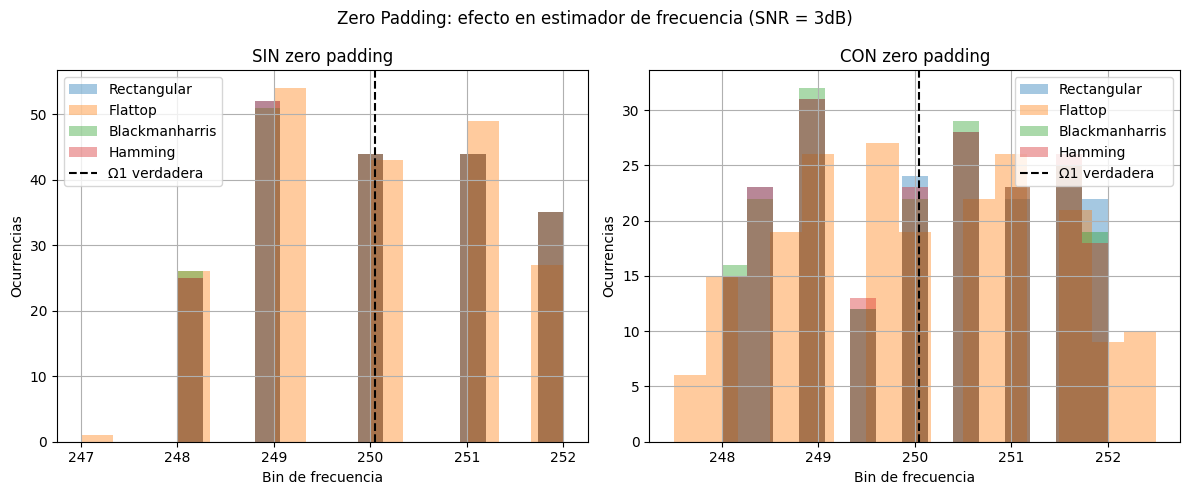

In [12]:
#%% SNR = 3dB
SNR = 3 # en dB
Ps = a0**2 / 2
Pr = Ps / (10**(SNR/10))
desvio = np.sqrt(Pr)

na = np.random.normal(0, desvio, size = (R, N)) # ruido

# Señal
s_mat_3 = a0 * np.sin(2 * np.pi * f * Ts) + na 

# Traspongo la señal para poder graficarla 
señal_t3 = np.transpose(s_mat_3)

plt.figure()
plt.title("Senoidal + ruido (SNR = 3dB)")
plt.plot(t, señal_t3)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]') # Es la densidad espectral de potencia 
plt.grid()
plt.show()

# FFT
eps = 1e-12
S_mat_3 = np.fft.fft(s_mat_3, axis = 1) / N
S_mat_modulo3 = np.abs(S_mat_3)
S_mat_dB3 = 10 * np.log10(2*(S_mat_modulo3)**2 + eps)
S_mat_dB3 = np.transpose(S_mat_dB3)

plt.figure()
plt.title("FFT senoidal + ruido (SNR = 3dB)")
plt.plot(ff, S_mat_dB3)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]') # Es la densidad espectral de potencia 
plt.xlim(0, fs/2)
plt.grid()
plt.show()
#%% Ventaneo SNR = 3dB
# RECTANGULAR
s_vent_R3 = s_mat_3 * windows.boxcar(N)

S_vent_R3 = np.fft.fft(s_vent_R3, axis=1) / N
S_vent_modulo_R3 = np.abs(S_vent_R3)
S_vent_R3_dB = 10 * np.log10(2*(S_vent_modulo_R3)**2 + eps)
S_vent_R3_dB = np.transpose(S_vent_R3_dB)

# FLATTOP
s_vent_F3 = s_mat_3 * windows.flattop(N)

S_vent_F3 = np.fft.fft(s_vent_F3, axis=1) / N
S_vent_modulo_F3 = np.abs(S_vent_F3)
S_vent_F3_dB = 10 * np.log10(2*(S_vent_modulo_F3)**2 + eps)
S_vent_F3_dB = np.transpose(S_vent_F3_dB)

# BLACKMANHARRIS
s_vent_B3 = s_mat_3 * windows.blackmanharris(N)

S_vent_B3 = np.fft.fft(s_vent_B3, axis=1) / N
S_vent_modulo_B3 = np.abs(S_vent_B3)
S_vent_B3_dB = 10 * np.log10(2*(S_vent_modulo_B3)**2 + eps)
S_vent_B3_dB = np.transpose(S_vent_B3_dB)

# HAMMING
s_vent_H3 = s_mat_3 * windows.hamming(N)

S_vent_H3 = np.fft.fft(s_vent_H3, axis=1) / N
S_vent_modulo_H3 = np.abs(S_vent_H3)
S_vent_H3_dB = 10 * np.log10(2*(S_vent_modulo_H3)**2 + eps)
S_vent_H3_dB = np.transpose(S_vent_H3_dB)

# Graficos
plt.figure()
plt.suptitle("Señal con ruido 3dB ventaneada")

plt.subplot(2,2,1)
plt.title("RECTANGULAR")
plt.plot(ff, S_vent_R3_dB)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]') # Es la densidad espectral de potencia 
plt.xlim(0, fs/2)
plt.grid()

plt.subplot(2,2,2)
plt.title("FLATTOP")
plt.plot(ff, S_vent_F3_dB)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]') # Es la densidad espectral de potencia 
plt.xlim(0, fs/2)
plt.grid()

plt.subplot(2,2,3)
plt.title("BLACKMANHARRIS")
plt.plot(ff, S_vent_B3_dB)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]') # Es la densidad espectral de potencia 
plt.xlim(0, fs/2)
plt.grid()

plt.subplot(2,2,4)
plt.title("HAMMING")
plt.plot(ff, S_vent_H3_dB)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]') # Es la densidad espectral de potencia 
plt.xlim(0, fs/2)
plt.grid()

plt.tight_layout()
plt.show()

#%% Estimador de amplitud SNR = 3dB
estimador_a_R3 = np.abs(S_vent_R3[:, N//4])*2
estimador_a_F3 = np.abs(S_vent_F3[:, N//4])*2
estimador_a_B3 = np.abs(S_vent_B3[:, N//4])*2
estimador_a_H3 = np.abs(S_vent_H3[:, N//4])*2

#%% SESGO Y VARIANZA SNR = 3dB
sesgo_R3 = np.mean(estimador_a_R3) - a0 
sesgo_F3 = np.mean(estimador_a_F3) - a0 
sesgo_B3 = np.mean(estimador_a_B3) - a0 
sesgo_H3 = np.mean(estimador_a_H3) - a0 

varianza_R3 = np.var(estimador_a_R3)
varianza_F3 = np.var(estimador_a_F3)
varianza_B3 = np.var(estimador_a_B3)
varianza_H3 = np.var(estimador_a_H3)

#%% Estimador de la frecuencia SNR = 3dB
estimador_f_R3 = np.argmax(np.abs(S_vent_R3[:, :N//2]), axis=1)
estimador_f_F3 = np.argmax(np.abs(S_vent_F3[:, :N//2]), axis=1)
estimador_f_B3 = np.argmax(np.abs(S_vent_B3[:, :N//2]), axis=1)
estimador_f_H3 = np.argmax(np.abs(S_vent_H3[:, :N//2]), axis=1)

#%% SESGO Y VARIANZA SNR = 3dB
sesgo_frec_R3 = np.mean(estimador_f_R3) - np.mean(omega1)
sesgo_frec_F3 = np.mean(estimador_f_F3) - np.mean(omega1)
sesgo_frec_B3 = np.mean(estimador_f_B3) - np.mean(omega1)
sesgo_frec_H3 = np.mean(estimador_f_H3) - np.mean(omega1)

varianza_frec_R3 = np.var(estimador_f_R3)
varianza_frec_F3 = np.var(estimador_f_F3)
varianza_frec_B3 = np.var(estimador_f_B3)
varianza_frec_H3 = np.var(estimador_f_H3)

#%% Efecto del zero padding en el estimador de frecuencia (SNR = 3dB)
N_zp = 2 * N  # 2000 puntos

# Rectangular
zp_W_R3 = np.fft.fft(s_vent_R3, n = N_zp, axis = 1)
estimador_f_zp_R3 = np.argmax(np.abs(zp_W_R3[:, :N_zp//2]), axis = 1) / 2
# Dividir por 2 porque los bins ahora son la mitad de anchos

# Flattop
zp_W_F3 = np.fft.fft(s_vent_F3, n = N_zp, axis  =1)
estimador_f_zp_F3 = np.argmax(np.abs(zp_W_F3[:, :N_zp//2]), axis = 1) / 2

# Blackmanharris
zp_W_B3 = np.fft.fft(s_vent_B3, n = N_zp, axis = 1)
estimador_f_zp_B3 = np.argmax(np.abs(zp_W_B3[:, :N_zp//2]), axis = 1) / 2

# Hamming
zp_W_H3 = np.fft.fft(s_vent_H3, n = N_zp, axis = 1)
estimador_f_zp_H3 = np.argmax(np.abs(zp_W_H3[:, :N_zp//2]), axis = 1) / 2

# Sesgo y varianza CON zero padding
sesgo_f_zp_R3 = np.mean(estimador_f_zp_R3) - np.mean(omega1)
sesgo_f_zp_F3 = np.mean(estimador_f_zp_F3) - np.mean(omega1)
sesgo_f_zp_B3 = np.mean(estimador_f_zp_B3) - np.mean(omega1)
sesgo_f_zp_H3 = np.mean(estimador_f_zp_H3) - np.mean(omega1)

var_f_zp_R3 = np.var(estimador_f_zp_R3)
var_f_zp_F3 = np.var(estimador_f_zp_F3)
var_f_zp_B3 = np.var(estimador_f_zp_B3)
var_f_zp_H3 = np.var(estimador_f_zp_H3)

#%% Histograma comparativo ZP vs sin ZP
plt.figure(figsize=(12, 5))
plt.suptitle("Zero Padding: efecto en estimador de frecuencia (SNR = 3dB)")

plt.subplot(1, 2, 1)
plt.title("SIN zero padding")
plt.hist(estimador_f_R3, label = 'Rectangular', alpha = 0.4, bins = 15)
plt.hist(estimador_f_F3,  label = 'Flattop', alpha = 0.4, bins = 15)
plt.hist(estimador_f_B3,  label = 'Blackmanharris', alpha = 0.4, bins = 15)
plt.hist(estimador_f_H3,  label = 'Hamming', alpha = 0.4, bins = 15)
plt.axvline(np.mean(omega1), color = 'k', linestyle = '--', label = 'Ω1 verdadera')
plt.xlabel('Bin de frecuencia')
plt.ylabel('Ocurrencias')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.title("CON zero padding")
plt.hist(estimador_f_zp_R3, label = 'Rectangular', alpha = 0.4, bins = 15)
plt.hist(estimador_f_zp_F3, label='Flattop', alpha = 0.4, bins = 15)
plt.hist(estimador_f_zp_B3, label='Blackmanharris', alpha = 0.4, bins = 15)
plt.hist(estimador_f_zp_H3 , label='Hamming', alpha = 0.4, bins = 15)
plt.axvline(np.mean(omega1), color = 'k', linestyle = '--', label = 'Ω1 verdadera')
plt.xlabel('Bin de frecuencia')
plt.ylabel('Ocurrencias')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

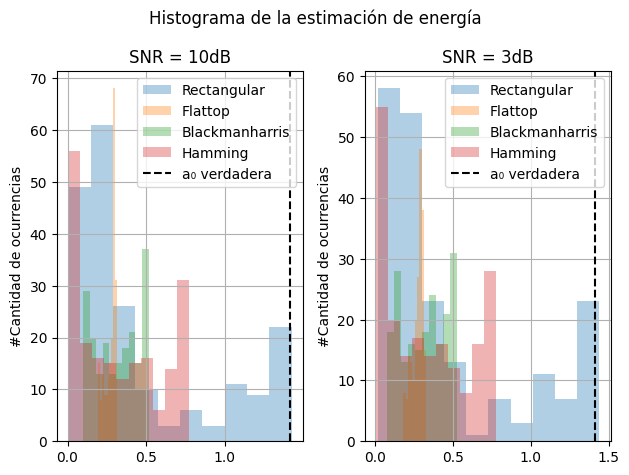

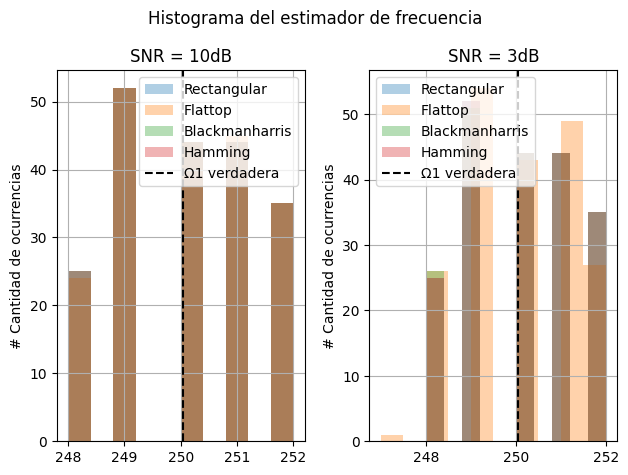

In [13]:
#%% Histogramas de los estimadores de amplitud 
trans = 0.35
bins = 10

# Histograma

plt.figure()
plt.suptitle("Histograma de la estimación de energía")

plt.subplot(1,2,1)
plt.title("SNR = 10dB")
plt.hist(estimador_a_R10, label = 'Rectangular', alpha = trans, bins = bins)
plt.hist(estimador_a_F10,label = 'Flattop', alpha = trans, bins = bins)
plt.hist(estimador_a_B10,label = 'Blackmanharris', alpha = trans, bins = bins)
plt.hist(estimador_a_H10,label = 'Hamming', alpha = trans, bins = bins)
plt.axvline(a0, color = 'k', linestyle = '--', label = 'a\u2080 verdadera')
plt.ylabel('#Cantidad de ocurrencias')
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.title("SNR = 3dB")
plt.hist(estimador_a_R3, label = 'Rectangular', alpha = trans, bins = bins)
plt.hist(estimador_a_F3,label = 'Flattop', alpha = trans, bins = bins)
plt.hist(estimador_a_B3,label = 'Blackmanharris', alpha = trans, bins = bins)
plt.hist(estimador_a_H3,label = 'Hamming', alpha = trans, bins = bins)
plt.axvline(a0, color = 'k', linestyle = '--', label = 'a\u2080 verdadera')
plt.ylabel('#Cantidad de ocurrencias')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

#%% Histogramas de los estimadores de frecuencia
plt.figure()
plt.suptitle("Histograma del estimador de frecuencia")

plt.subplot(1,2,1)
plt.title("SNR = 10dB") 
plt.hist(estimador_f_R10, label = 'Rectangular',    alpha = trans, bins = 10)
plt.hist(estimador_f_F10, label = 'Flattop',        alpha = trans, bins = 10)
plt.hist(estimador_f_B10, label = 'Blackmanharris', alpha = trans, bins = 10)
plt.hist(estimador_f_H10, label = 'Hamming',        alpha = trans, bins = 10)
plt.axvline(np.mean(omega1), color = 'k', linestyle = '--', label = 'Ω1 verdadera')
# plt.xlabel('Frecuencia [Hz]')
plt.ylabel('# Cantidad de ocurrencias')
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.title("SNR = 3dB")
plt.hist(estimador_f_R3, label = 'Rectangular',    alpha = trans, bins = 10)
plt.hist(estimador_f_F3, label = 'Flattop',        alpha = trans, bins = 10)
plt.hist(estimador_f_B3, label = 'Blackmanharris', alpha = trans, bins = 10)
plt.hist(estimador_f_H3, label = 'Hamming',        alpha = trans, bins = 10)
plt.axvline(np.mean(omega1), color = 'k', linestyle = '--', label = 'Ω1 verdadera')
# plt.xlabel('Frecuencia [Hz]')
plt.ylabel('# Cantidad de ocurrencias')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


# <h3>CONCLUSIONES<h3>
El estimador de energia es muy dependiente de la ventana

Para todo lo que sea energia, el desparramo de la misma depende de la energia

En contraposicion, el estimador de la frecuencia no depende de la energia --> forma concava

Zero padding --> va a bajar la varianza porque estoy midiendo en mas puntos intermedios

Tengo una mejor resolucion espectral ficticia pero efectiva a la hora de estimar la frecuencia 

El ruido va a tener mas relevancia en la estimacion de frecuencia que en el de energia. 

na es un proceso gaussiano incorrelado, cuando promediamos eso tiende a cero

Da lo mismo promediar en las realizaciones que en el tiempo (valor nulo) --> ergodicidad

In [5]:
#%% IMPRESION DE TABLAS EN TERMINAL
print("\n" + "="*60)
print("ESTIMACIÓN DE AMPLITUD")
print("="*60)
print(f"{'Ventana':<16}{'sa (10dB)':>12}{'va (10dB)':>12}{'sa (3dB)':>12}{'va (3dB)':>12}")
print(f"{'Rectangular':<16}{sesgo_amp_R10:>12.4f}{varianza_amp_R10:>12.5f}{sesgo_R3:>12.4f}{varianza_R3:>12.5f}")
print(f"{'Flat-top':<16}{sesgo_amp_F10:>12.4f}{varianza_amp_F10:>12.5f}{sesgo_F3:>12.4f}{varianza_F3:>12.5f}")
print(f"{'Blackmanharris':<16}{sesgo_amp_B10:>12.4f}{varianza_amp_B10:>12.5f}{sesgo_B3:>12.4f}{varianza_B3:>12.5f}")
print(f"{'Hamming':<16}{sesgo_amp_H10:>12.4f}{varianza_amp_H10:>12.5f}{sesgo_H3:>12.4f}{varianza_H3:>12.5f}")

print("\n" + "="*60)
print("ESTIMACIÓN DE FRECUENCIA")
print("="*60)
print(f"{'Ventana':<16}{'sf (10dB)':>12}{'vf (10dB)':>12}{'sf (3dB)':>12}{'vf (3dB)':>12}")
print(f"{'Rectangular':<16}{sesgo_frec_R10:>12.4f}{varianza_frec_R10:>12.4f}{sesgo_frec_R3:>12.4f}{varianza_frec_R3:>12.4f}")
print(f"{'Flat-top':<16}{sesgo_frec_F10:>12.4f}{varianza_frec_F10:>12.4f}{sesgo_frec_F3:>12.4f}{varianza_frec_F3:>12.4f}")
print(f"{'Blackmanharris':<16}{sesgo_frec_B10:>12.4f}{varianza_frec_B10:>12.4f}{sesgo_frec_B3:>12.4f}{varianza_frec_B3:>12.4f}")
print(f"{'Hamming':<16}{sesgo_frec_H10:>12.4f}{varianza_frec_H10:>12.4f}{sesgo_frec_H3:>12.4f}{varianza_frec_H3:>12.4f}")


ESTIMACIÓN DE AMPLITUD
Ventana            sa (10dB)   va (10dB)    sa (3dB)    va (3dB)
Rectangular          -0.8933     0.21901     -0.8928     0.21561
Flat-top             -1.1362     0.00116     -1.1361     0.00118
Blackmanharris       -1.0838     0.01856     -1.0844     0.01831
Hamming              -1.0591     0.07466     -1.0599     0.07362

ESTIMACIÓN DE FRECUENCIA
Ventana            sf (10dB)   vf (10dB)    sf (3dB)    vf (3dB)
Rectangular           0.0096      1.5520      0.0096      1.5520
Flat-top             -0.0004      1.5030     -0.0454      1.5400
Blackmanharris        0.0046      1.5675      0.0196      1.5508
Hamming              -0.0004      1.5630      0.0096      1.5620
